# Titanic Survival Prediction

In this notebook, we develop a machine learning model to predict whether a passenger survived the Titanic disaster. We perform data preprocessing, exploratory data analysis (EDA), model training, and evaluation. The dataset includes features such as age, gender, ticket class, fare, and cabin information.

# Load and Inspect Data

### Step 1: Load and Inspect Data

We start by loading the dataset and viewing the first few rows to understand its structure.

In [2]:
import pandas as pd
# Load dataset
df = pd.read_csv('/kaggle/input/test-file/tested.csv')

In [3]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


# Data Preprocessing 

### Step 2: Data Preprocessing

- **Drop irrelevant features** like `Name`, `Ticket`, `Cabin`, and `PassengerId`.
- **Handle missing values** by filling `Age` and `Fare` with their respective medians.
- **Encode categorical variables** like `Sex` and `Embarked` using `LabelEncoder`.
- **Normalize numerical data** using `StandardScaler` for better model performance.

In [4]:
# Drop columns that are less useful
df.drop(['Name', 'Ticket', 'Cabin', 'PassengerId'], axis=1, inplace=True, errors='ignore')

# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Encode categorical features
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])  # male:1, female:0
df['Embarked'] = le.fit_transform(df['Embarked'])

# Scale numerical features
scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

# Exploratory Data Analysis (EDA)

### Step 3: Exploratory Data Analysis (EDA)

Visualizations help us understand the survival distribution across different features:
- **Gender:** More women survived than men.
- **Class:** First-class passengers had higher survival rates.
- **Age:** Younger passengers had slightly better chances of survival.

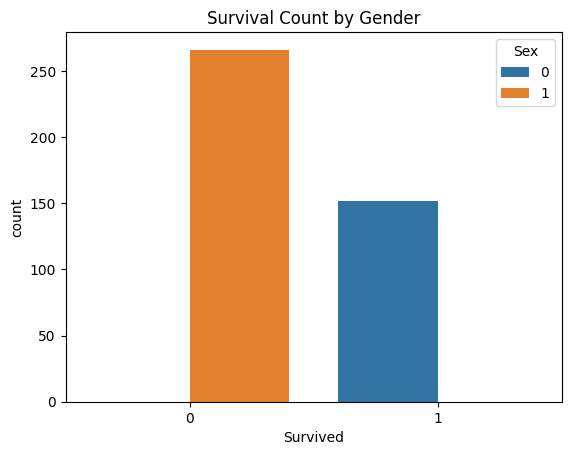

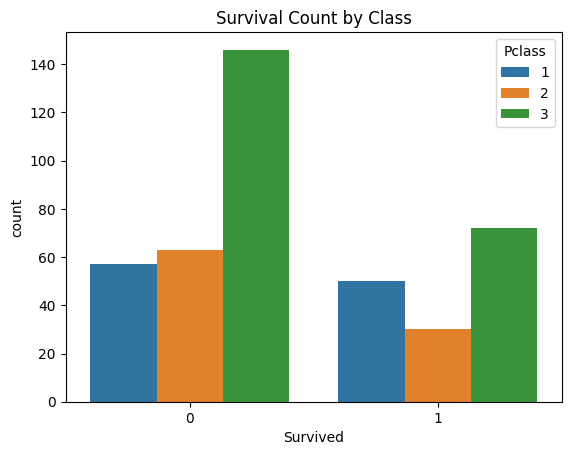

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


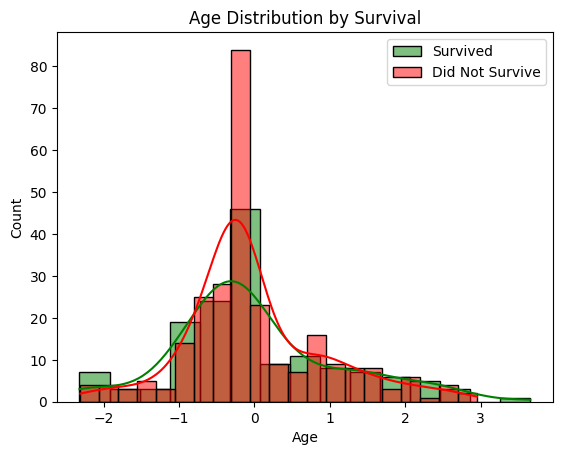

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Survival by gender
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival Count by Gender')
plt.show()

# Survival by class
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title('Survival Count by Class')
plt.show()

# Age distribution
sns.histplot(df[df['Survived'] == 1]['Age'], kde=True, color='green', label='Survived')
sns.histplot(df[df['Survived'] == 0]['Age'], kde=True, color='red', label='Did Not Survive')
plt.legend()
plt.title('Age Distribution by Survival')
plt.show()

# Model Training and Evaluation

### Step 4: Model Training and Evaluation

We train a **Random Forest Classifier**, split the data 80/20 for training/testing, and evaluate the model using:
- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**
- **Confusion Matrix**

The model provides a good balance between precision and recall, ensuring robust survival prediction.

RandomForestClassifier(random_state=42)
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



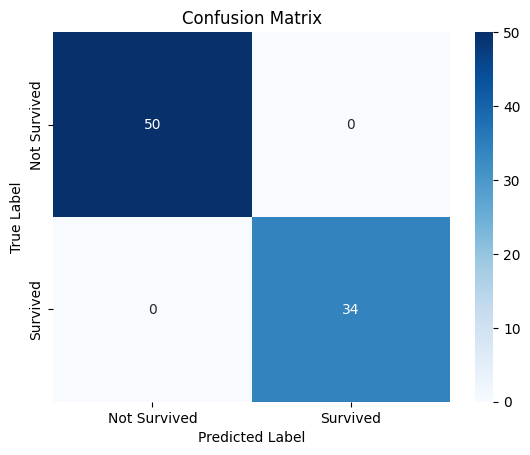

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(model)
# Predict
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()